# Train/Val Distribution by Dataset Families and Sub-Datasets

This notebook reports three things:
- `train` vs `val` counts and fractions by high-level dataset family (`qm7x`, `qm7`, `qm9`, `spice`, etc.)
- detailed `dataset/sub_dataset` distributions
- coverage + Hessian audit metrics (unprocessed molecules + unique Hessian counts), if audit outputs are present


In [1]:
from pathlib import Path
from typing import Optional


def find_repo_root(start: Optional[Path] = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for p in [cur, *cur.parents]:
        if (p / 'train' / 'train_detanet.py').exists():
            return p
    raise RuntimeError('Could not locate repo root containing train/train_detanet.py')


REPO_ROOT = find_repo_root()
print('REPO_ROOT =', REPO_ROOT)

# --- Input selection ---
# Option A: scan shards directly (raw mode)
# Prefer a shard list file with one shard path per line.
# Example: shard_list = '/tmp/all_shards.txt'
shard_list = None

# Or set shard_dir to scan shard_*.pt recursively.
# Example: shard_dir = '/fsx/processed_all'
shard_dir = None

# Auto-detect if both are None.
auto_candidates = [
    '/tmp/all_shards.txt',
    '/fsx/processed_all',
    '/tmp/polar_64.txt',
    'samples/shard_000013.pt',
]

# Option B: precomputed mode (fast, no shard loading)
# If these CSVs exist and use_precomputed_if_available=True, the notebook uses them.
precomputed_dir = REPO_ROOT / 'analysis/remote_polar_all_shards_distribution'
use_precomputed_if_available = True


# Coverage + Hessian audit outputs (optional)
coverage_audit_dir = REPO_ROOT / 'analysis/remote_polar_hessian_coverage_audit'
use_coverage_audit_if_available = True

# --- Split config (must match your train command) ---
task = 'polar'
split_method = 'scaffold'            # 'hash' or 'scaffold'
split_key = 'mol_key'
scaffold_group_key = 'mol_key'
scaffold_smiles_key = 'smile'
scaffold_include_chirality = False
scaffold_fallback = 'molecule'
split_seed = 123
split_train = 0.7
split_val = 0.1

# --- Scan controls ---
skip_nonfinite = True
max_shards = 0                       # 0 = all shards
track_molecule_conflicts = True
progress_every = 50

# --- Outputs ---
output_dir = REPO_ROOT / 'analysis/split_distribution_outputs'
output_dir.mkdir(parents=True, exist_ok=True)
print('output_dir =', output_dir.resolve())


REPO_ROOT = /Users/rahul/Desktop/hp-proteins-ml
output_dir = /Users/rahul/Desktop/hp-proteins-ml/analysis/split_distribution_outputs


In [2]:
import hashlib
import math
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import pandas as pd
import torch

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

from IPython.display import display

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


# Prefer using training-code split helpers directly. If import fails
# (e.g., env lacks torch_geometric), fall back to local equivalents.
try:
    from train.train_detanet import _resolve_split_token, _split_label
except Exception as import_exc:
    print('Falling back to local split helpers:', repr(import_exc))

    _RDKIT_CACHE: Optional[tuple[Any, Any]] = None

    def _split_bucket(key: str, seed: int) -> int:
        digest = hashlib.md5(f"{seed}:{key}".encode()).hexdigest()
        return int(digest, 16) % 1000

    def _split_label(key: str, seed: int, train_ratio: float, val_ratio: float) -> str:
        bucket = _split_bucket(key, seed)
        train_cutoff = int(train_ratio * 1000)
        val_cutoff = int((train_ratio + val_ratio) * 1000)
        if bucket < train_cutoff:
            return 'train'
        if bucket < val_cutoff:
            return 'val'
        return 'test'

    def _normalize_split_key(value) -> str:
        if torch.is_tensor(value):
            if value.numel() == 1:
                value = value.item()
            else:
                value = value.flatten()[0].item()
        return str(value)

    def _ensure_rdkit_available() -> tuple[Any, Any]:
        global _RDKIT_CACHE
        if _RDKIT_CACHE is not None:
            return _RDKIT_CACHE
        from rdkit import Chem
        from rdkit import RDLogger
        from rdkit.Chem.Scaffolds import MurckoScaffold
        RDLogger.DisableLog('rdApp.error')
        _RDKIT_CACHE = (Chem, MurckoScaffold)
        return _RDKIT_CACHE

    def _resolve_molecule_key(item, group_key: str = 'mol_key') -> Optional[str]:
        key_val = getattr(item, group_key, None)
        if key_val is None and group_key != 'mol_key':
            key_val = getattr(item, 'mol_key', None)
        if key_val is None and group_key != 'number':
            key_val = getattr(item, 'number', None)
        if key_val is None:
            return None
        return _normalize_split_key(key_val)

    def _resolve_smiles_string(item, smiles_key: str = 'smile') -> Optional[str]:
        keys = [smiles_key]
        for fallback in ('smile', 'smiles', 'canonical_smiles'):
            if fallback not in keys:
                keys.append(fallback)
        for key in keys:
            value = getattr(item, key, None)
            if value is None:
                continue
            if isinstance(value, bytes):
                value = value.decode('utf-8', errors='ignore')
            if isinstance(value, str):
                value = value.strip()
                if value and any(ch.isalpha() for ch in value):
                    return value
        return None

    def _canonicalize_and_scaffold_smiles(smiles: str, include_chirality: bool = False):
        Chem, MurckoScaffold = _ensure_rdkit_available()
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, None
        for atom in mol.GetAtoms():
            if atom.GetAtomMapNum():
                atom.SetAtomMapNum(0)
        canonical = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=include_chirality)
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=include_chirality)
        if scaffold:
            scaf_mol = Chem.MolFromSmiles(scaffold)
            if scaf_mol is not None:
                scaffold = Chem.MolToSmiles(scaf_mol, canonical=True, isomericSmiles=include_chirality)
        return canonical, scaffold

    def _resolve_split_token(
        item,
        *,
        split_method: str,
        split_key: str,
        scaffold_group_key: str,
        scaffold_smiles_key: str,
        scaffold_include_chirality: bool,
        scaffold_fallback: str,
        split_cache: Optional[Dict[str, str]] = None,
    ) -> Optional[str]:
        split_method = split_method.lower()
        if split_method == 'hash':
            key_val = getattr(item, split_key, None)
            if key_val is None and split_key != 'number':
                key_val = getattr(item, 'number', None)
            if key_val is None:
                return None
            return _normalize_split_key(key_val)

        if split_method != 'scaffold':
            raise ValueError(f'unknown split method: {split_method}')

        molecule_key = _resolve_molecule_key(item, scaffold_group_key)
        if molecule_key is not None and split_cache is not None:
            cached = split_cache.get(molecule_key)
            if cached is not None:
                return cached

        smiles = _resolve_smiles_string(item, scaffold_smiles_key)
        if smiles is None:
            if molecule_key is None:
                return None
            token = f'MOLECULE::{molecule_key}'
            if split_cache is not None:
                split_cache[molecule_key] = token
            return token

        canonical_smiles, scaffold = _canonicalize_and_scaffold_smiles(
            smiles,
            include_chirality=scaffold_include_chirality,
        )
        if scaffold:
            token = f'SCAFFOLD::{scaffold}'
        elif scaffold_fallback == 'molecule':
            fallback = canonical_smiles or molecule_key or smiles
            token = f'MOLECULE::{fallback}'
        else:
            token = 'SCAFFOLD::__EMPTY__'

        if molecule_key is not None and split_cache is not None:
            split_cache[molecule_key] = token
        return token


plt.style.use('seaborn-v0_8-whitegrid')


def _resolve_path(candidate: str | Path) -> Path:
    p = Path(candidate).expanduser()
    if p.exists():
        return p.resolve()
    q = (REPO_ROOT / p).resolve()
    return q


def list_shards(shard_list_path=None, shard_dir_path=None, auto_paths=None):
    if shard_list_path is not None:
        p = _resolve_path(shard_list_path)
        if not p.exists():
            raise FileNotFoundError(f'shard_list not found: {p}')
        paths = []
        for raw in p.read_text().splitlines():
            raw = raw.strip()
            if not raw:
                continue
            # Support list files with extra columns by using the first token.
            paths.append(raw.split()[0])
        return paths

    if shard_dir_path is not None:
        p = _resolve_path(shard_dir_path)
        if not p.exists():
            raise FileNotFoundError(f'shard_dir not found: {p}')
        return sorted(str(x) for x in p.rglob('shard_*.pt'))

    auto_paths = auto_paths or []
    for cand in auto_paths:
        p = _resolve_path(cand)
        if p.exists() and p.is_file() and p.name.endswith('.txt'):
            print(f'auto-detected shard list: {p}')
            return list_shards(shard_list_path=p)
        if p.exists() and p.is_dir():
            # Treat candidate directory as shard root.
            found = sorted(str(x) for x in p.rglob('shard_*.pt'))
            if found:
                print(f'auto-detected shard dir: {p} (n={len(found)})')
                return found
        if p.exists() and p.is_file() and p.name.startswith('shard_') and p.suffix == '.pt':
            print(f'auto-detected single shard: {p}')
            return [str(p)]

    raise ValueError('Provide shard_list or shard_dir (or update auto_candidates).')


def is_valid_item(item, task_name, do_skip_nonfinite=True):
    target = getattr(item, task_name, None)
    pos = getattr(item, 'pos', None)
    if target is None or pos is None:
        return False
    if not do_skip_nonfinite:
        return True

    if torch.is_tensor(target) and not torch.isfinite(target).all().item():
        return False
    if (not torch.is_tensor(target)) and isinstance(target, (float, int)) and not math.isfinite(target):
        return False
    if torch.is_tensor(pos) and not torch.isfinite(pos).all().item():
        return False
    return True


def infer_dataset_parts(shard_path, item_source=None):
    p = Path(shard_path)
    parts = list(p.parts)

    dataset = 'unknown_dataset'
    sub_dataset = 'unknown_subdataset'
    run_name = 'unknown_run'

    rank_idx = next((i for i, x in enumerate(parts) if x.startswith('rank_')), None)
    run_prefixes = ('run-', 'sanity-', 'processed_all')

    if rank_idx is not None:
        p1 = parts[rank_idx - 1] if rank_idx >= 1 else ''
        p2 = parts[rank_idx - 2] if rank_idx >= 2 else ''
        p3 = parts[rank_idx - 3] if rank_idx >= 3 else ''

        # Handles both layouts:
        # 1) .../<dataset>/<sub_dataset>/rank_x/shard_*.pt
        # 2) .../<dataset>/rank_x/shard_*.pt
        if p2 and not p2.startswith(run_prefixes):
            dataset = p2
            sub_dataset = p1 or 'default'
            run_name = p3 or 'unknown_run'
        else:
            dataset = p1 or 'unknown_dataset'
            sub_dataset = 'default'
            run_name = p2 or p3 or 'unknown_run'
    elif len(parts) >= 3:
        dataset = parts[-3]
        sub_dataset = parts[-2]

    if dataset.startswith('unknown') and item_source is not None:
        stem = Path(str(item_source)).stem
        dataset = stem
        sub_dataset = stem

    return dataset, sub_dataset, run_name


# --- Dataset family classification config ---
# Add/adjust aliases if your local data names differ.
family_patterns = [
    ('qm7x', ('qm7x', 'qm7-x', 'datasets--qm7x')),
    ('qm7', ('qm7',)),
    ('qm9', ('qm9', 'gdb9', 'gdb-9')),
    ('spice', ('spice', 'spice-2.0.1')),
    ('des5m', ('des5m', 'donchev')),
    ('raman_chembl', ('raman_chembl', 'raman-chembl', 'ramanchembl')),
    ('qdpi', ('qdpi',)),
    ('nabla', ('nabla', 'nabla2', 'nabladft')),
    ('ani', ('ani', 'ani1', 'ani-1', 'ani2', 'ani-2')),
    ('md17', ('md17', 'rmd17')),
    ('iso17', ('iso17',)),
    ('pdb', ('pdb',)),
    ('sdf', ('sdf',)),
    ('summary_csv', ('summary_csv', 'summary.csv')),
    ('db', ('db',)),
]

# Optional exact-token overrides after normalization.
# Example (uncomment if needed):
# manual_family_aliases = {'summary.csv.gz': 'qm9'}
manual_family_aliases: Dict[str, str] = {}
unknown_family = 'unknown'


def _normalize_token(value: Any) -> str:
    if value is None:
        return ''
    if torch.is_tensor(value):
        if value.numel() == 1:
            value = value.item()
        else:
            value = value.flatten()[0].item()
    text = str(value).strip().lower().replace('\\', '/')
    text = re.sub(r'[^a-z0-9._/+:-]+', '_', text)
    return text


def _family_candidates(shard_path, *, item_source=None, item_subset=None, dataset=None, sub_dataset=None, run_name=None):
    p = Path(str(shard_path))
    raw = [
        item_source,
        item_subset,
        dataset,
        sub_dataset,
        run_name,
        p.name,
        p.stem,
        str(p),
        *p.parts,
    ]

    cands = []
    seen = set()
    for entry in raw:
        norm = _normalize_token(entry)
        if not norm:
            continue
        # include both full token and slash-split fragments for robust matching
        for token in [norm, *[x for x in norm.split('/') if x]]:
            if token and token not in seen:
                seen.add(token)
                cands.append(token)
    return cands


def classify_dataset_family(
    shard_path,
    *,
    item_source=None,
    item_subset=None,
    dataset=None,
    sub_dataset=None,
    run_name=None,
):
    cands = _family_candidates(
        shard_path,
        item_source=item_source,
        item_subset=item_subset,
        dataset=dataset,
        sub_dataset=sub_dataset,
        run_name=run_name,
    )

    # manual aliases first
    for token in cands:
        if token in manual_family_aliases:
            return manual_family_aliases[token]

    # keyword families next
    for family, keywords in family_patterns:
        for token in cands:
            for kw in keywords:
                kw_norm = _normalize_token(kw)
                if kw_norm and kw_norm in token:
                    return family

    return unknown_family


/Users/rahul/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/8l/vgsnzp1s0g54ndf86zjdlwc00000gn/T/matplotlib-a290v7fb because there was an issue with the default path (/Users/rahul/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [3]:
import json

precomputed_mode = False
precomputed_summary = {}

row_counts = Counter()      # (family, dataset, sub_dataset, split) -> count
family_counts = Counter()   # (family, split) -> count
source_counts = Counter()   # (source, split) -> count
subset_counts = Counter()   # (subset, split) -> count
split_counts = Counter()    # split -> count
meta_counts = Counter()

split_cache = {}
mol_splits = defaultdict(set)

family_df = pd.DataFrame()
source_df = pd.DataFrame()
subset_df = pd.DataFrame()
dist_df = pd.DataFrame()

pre_dir = None
if precomputed_dir is not None:
    pre_dir = _resolve_path(precomputed_dir)
pre_family_csv = (pre_dir / 'family_split_distribution.csv') if pre_dir else None
pre_dataset_csv = (pre_dir / 'dataset_split_distribution.csv') if pre_dir else None
pre_source_csv = (pre_dir / 'source_split_distribution.csv') if pre_dir else None
pre_summary_json = (pre_dir / 'summary.json') if pre_dir else None

if (
    use_precomputed_if_available
    and pre_family_csv is not None
    and pre_dataset_csv is not None
    and pre_family_csv.exists()
    and pre_dataset_csv.exists()
):
    precomputed_mode = True
    print(f'Using precomputed CSVs from: {pre_dir}')

    pre_family_df = pd.read_csv(pre_family_csv)
    dist_df = pd.read_csv(pre_dataset_csv)

    if pre_source_csv is not None and pre_source_csv.exists():
        source_df = pd.read_csv(pre_source_csv)
    else:
        source_df = pd.DataFrame(columns=['source', 'split', 'count'])

    subset_df = pd.DataFrame(columns=['subset', 'split', 'count'])

    if pre_summary_json is not None and pre_summary_json.exists():
        precomputed_summary = json.loads(pre_summary_json.read_text())

    if {'family', 'train', 'val'}.issubset(pre_family_df.columns):
        tmp_rows = []
        for _, r in pre_family_df.iterrows():
            fam = r['family']
            for sp in ['train', 'val', 'test']:
                if sp in pre_family_df.columns:
                    tmp_rows.append({'family': fam, 'split': sp, 'count': int(r[sp])})
        family_df = pd.DataFrame(tmp_rows)

    if not dist_df.empty and {'split', 'count'}.issubset(dist_df.columns):
        split_counts.update(dist_df.groupby('split')['count'].sum().to_dict())

    if precomputed_summary:
        meta_counts.update(precomputed_summary.get('meta', {}))

    print('split_counts =', dict(split_counts))
    if precomputed_summary:
        print('precomputed summary loaded from summary.json')

else:
    shard_paths = list_shards(
        shard_list_path=shard_list,
        shard_dir_path=shard_dir,
        auto_paths=auto_candidates,
    )
    if max_shards and max_shards > 0:
        shard_paths = shard_paths[:max_shards]

    print('num_shards =', len(shard_paths))
    if len(shard_paths) == 0:
        raise RuntimeError('No shards found.')

    for idx, shard_path in enumerate(tqdm(shard_paths, desc='Scanning shards'), start=1):
        try:
            items = torch.load(shard_path, map_location='cpu', weights_only=False)
        except Exception:
            meta_counts['shard_load_errors'] += 1
            continue

        for item in items:
            meta_counts['items_total'] += 1
            if not is_valid_item(item, task, do_skip_nonfinite=skip_nonfinite):
                continue
            meta_counts['items_valid'] += 1

            token = _resolve_split_token(
                item,
                split_method=split_method,
                split_key=split_key,
                scaffold_group_key=scaffold_group_key,
                scaffold_smiles_key=scaffold_smiles_key,
                scaffold_include_chirality=scaffold_include_chirality,
                scaffold_fallback=scaffold_fallback,
                split_cache=split_cache,
            )
            if token is None:
                meta_counts['items_missing_split_token'] += 1
                continue

            split = _split_label(token, split_seed, split_train, split_val)
            item_source = getattr(item, 'source', None)
            item_subset = getattr(item, 'subset', None)
            mol_key = getattr(item, 'mol_key', None)

            dataset, sub_dataset, run_name = infer_dataset_parts(shard_path, item_source=item_source)
            family = classify_dataset_family(
                shard_path,
                item_source=item_source,
                item_subset=item_subset,
                dataset=dataset,
                sub_dataset=sub_dataset,
                run_name=run_name,
            )

            row_counts[(family, dataset, sub_dataset, split)] += 1
            family_counts[(family, split)] += 1
            source_counts[(str(item_source or 'unknown_source'), split)] += 1
            subset_counts[(str(item_subset or 'unknown_subset'), split)] += 1
            split_counts[split] += 1
            if track_molecule_conflicts and mol_key is not None:
                mol_splits[str(mol_key)].add(split)

        if progress_every > 0 and idx % progress_every == 0:
            print(f'processed {idx}/{len(shard_paths)} shards | valid_items={meta_counts["items_valid"]}')

    dist_rows = [
        {'family': fam, 'dataset': d, 'sub_dataset': sd, 'split': s, 'count': c}
        for (fam, d, sd, s), c in row_counts.items()
    ]
    dist_df = pd.DataFrame(dist_rows)

    family_df = pd.DataFrame(
        [{'family': fam, 'split': s, 'count': c} for (fam, s), c in family_counts.items()]
    )
    source_df = pd.DataFrame(
        [{'source': src, 'split': s, 'count': c} for (src, s), c in source_counts.items()]
    )
    subset_df = pd.DataFrame(
        [{'subset': sub, 'split': s, 'count': c} for (sub, s), c in subset_counts.items()]
    )

print('meta_counts =', dict(meta_counts))
print('split_counts =', dict(split_counts))
if not family_df.empty:
    display(family_df.head())
if not dist_df.empty:
    display(dist_df.head())


Using precomputed CSVs from: /Users/rahul/Desktop/hp-proteins-ml/analysis/remote_polar_all_shards_distribution
split_counts = {'test': 541128, 'train': 1470761, 'val': 154591}
precomputed summary loaded from summary.json
meta_counts = {'items_total': 2166480, 'items_valid': 2166480}
split_counts = {'test': 541128, 'train': 1470761, 'val': 154591}


,family,split,count
0,spice,train,803836
1,spice,val,111071
2,spice,test,278943
3,qm7x,train,618544
4,qm7x,val,37048


,family,dataset,sub_dataset,split,count
0,des5m,des5m,default,test,2105
1,des5m,des5m,default,train,7100
2,des5m,des5m,default,val,795
3,qm7x,qm7x,1000,test,67681
4,qm7x,qm7x,1000,train,318756


train_total=1470761 | val_total=154591
precomputed_mode=True (loaded summary.json)
precomputed split_counts: {'test': 541128, 'train': 1470761, 'val': 154591}


split,train,val,train_fraction,val_fraction,val_minus_train_fraction,val_to_train_ratio
family,,,,,,
spice,803836,111071,0.546544,0.718483,0.171939,0.138176
qm7x,618544,37048,0.420561,0.239652,-0.180909,0.059895
qm9,41281,5677,0.028068,0.036723,0.008655,0.137521
des5m,7100,795,0.004827,0.005143,0.000315,0.111972


split,train,val
dataset,,
spice-2.0.1,803836,111071
qm7x,618544,37048
summary_csv,41281,5677
des5m,7100,795


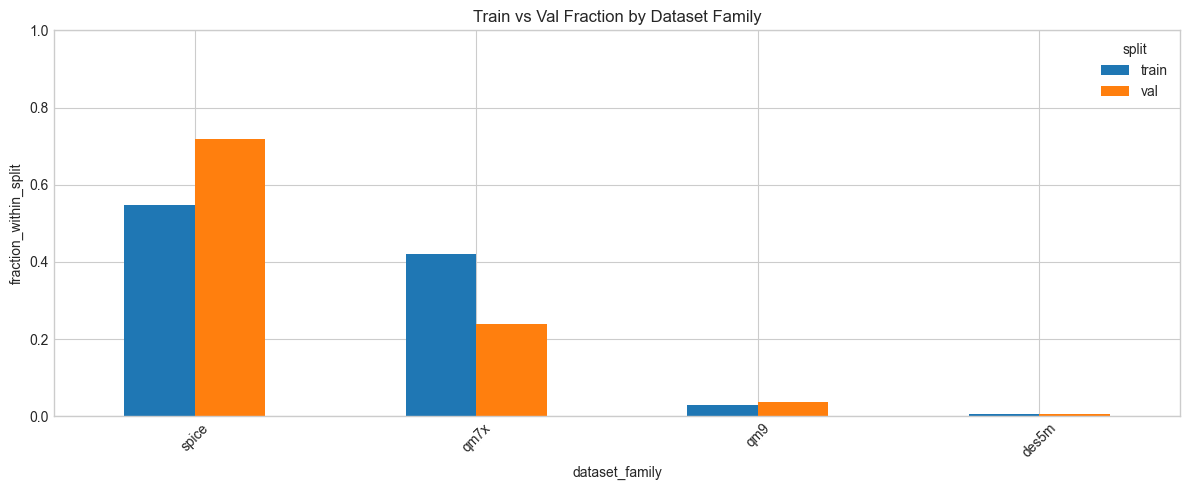

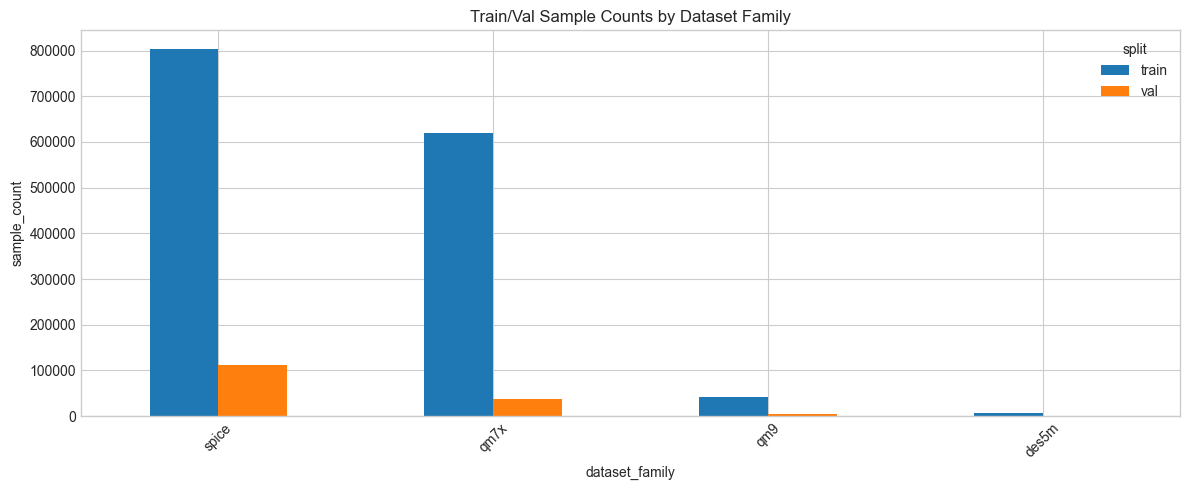

In [4]:
if dist_df.empty:
    raise RuntimeError('No distribution rows found. Check shard paths/precomputed CSVs and task field.')

# 1) Family-level count and fraction table (qm7/qm9/spice/etc across train/val)
family_summary = (
    dist_df[dist_df['split'].isin(['train', 'val'])]
    .groupby(['family', 'split'])['count']
    .sum()
    .unstack(fill_value=0)
)

for col in ['train', 'val']:
    if col not in family_summary.columns:
        family_summary[col] = 0

family_summary = family_summary[['train', 'val']]
train_total = int(family_summary['train'].sum())
val_total = int(family_summary['val'].sum())

if train_total > 0:
    family_summary['train_fraction'] = family_summary['train'] / train_total
else:
    family_summary['train_fraction'] = 0.0

if val_total > 0:
    family_summary['val_fraction'] = family_summary['val'] / val_total
else:
    family_summary['val_fraction'] = 0.0

family_summary['val_minus_train_fraction'] = family_summary['val_fraction'] - family_summary['train_fraction']
family_summary['val_to_train_ratio'] = family_summary['val'] / family_summary['train'].replace(0, pd.NA)
family_summary = family_summary.sort_values('train_fraction', ascending=False)

print(f'train_total={train_total} | val_total={val_total}')
if precomputed_mode and precomputed_summary:
    print('precomputed_mode=True (loaded summary.json)')
    print('precomputed split_counts:', precomputed_summary.get('split_counts', {}))

display(family_summary)

# 2) Path-level dataset summary (useful to drill into run output dirs)
dataset_summary = (
    dist_df[dist_df['split'].isin(['train', 'val'])]
    .groupby(['dataset', 'split'])['count']
    .sum()
    .unstack(fill_value=0)
)
for col in ['train', 'val']:
    if col not in dataset_summary.columns:
        dataset_summary[col] = 0

dataset_summary = dataset_summary[['train', 'val']].sort_values('train', ascending=False)
display(dataset_summary)

# 3) Plot fractions by family (train vs val on same chart)
frac_plot = family_summary[['train_fraction', 'val_fraction']].rename(
    columns={'train_fraction': 'train', 'val_fraction': 'val'}
)
ax = frac_plot.plot(kind='bar', figsize=(12, 5))
ax.set_title('Train vs Val Fraction by Dataset Family')
ax.set_ylabel('fraction_within_split')
ax.set_xlabel('dataset_family')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Optional count plot for sanity checks.
ax = family_summary[['train', 'val']].plot(kind='bar', figsize=(12, 5))
ax.set_title('Train/Val Sample Counts by Dataset Family')
ax.set_ylabel('sample_count')
ax.set_xlabel('dataset_family')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


split,family,dataset,sub_dataset,train,val,total
0,des5m,des5m,default,7100,795,7895
1,qm7x,qm7x,1000,318756,23211,341967
2,qm7x,qm7x,2000,267044,13837,280881
3,qm7x,qm7x,3000,32744,0,32744
4,qm9,summary_csv,default,41281,5677,46958
5,spice,spice-2.0.1,default,803836,111071,914907


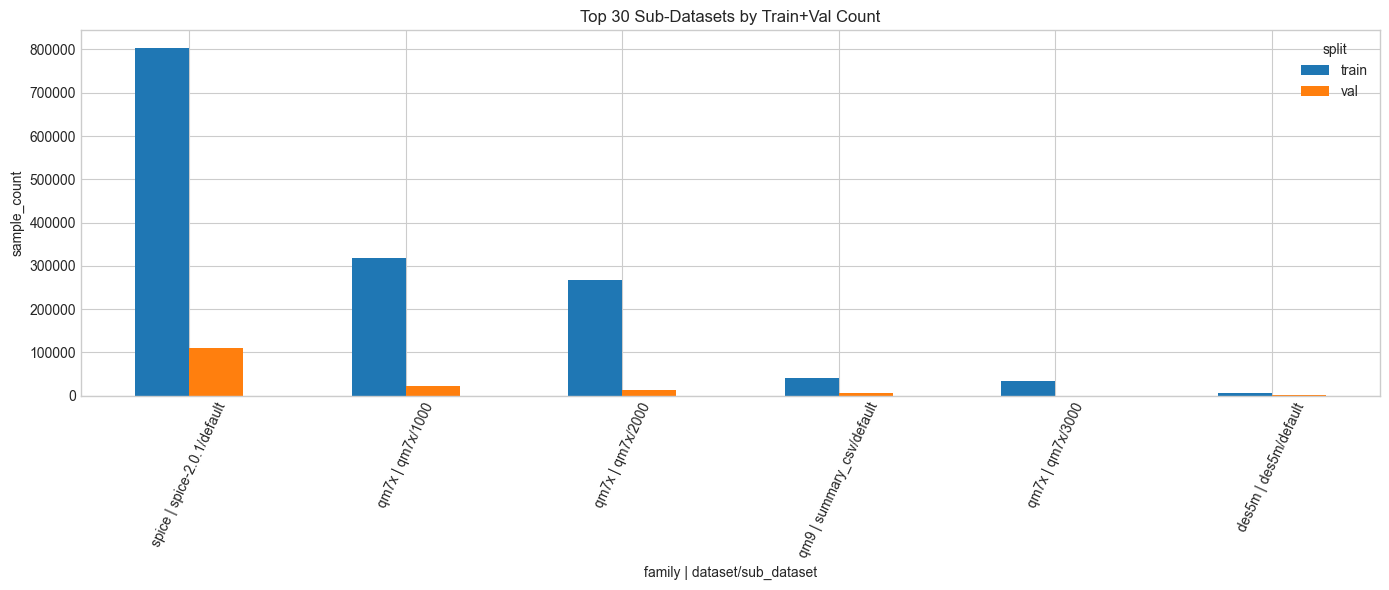

split,train,val
family_dataset_sub,,
des5m | des5m/default,7100,795
qm7x | qm7x/1000,318756,23211
qm7x | qm7x/2000,267044,13837
qm7x | qm7x/3000,32744,0
qm9 | summary_csv/default,41281,5677
spice | spice-2.0.1/default,803836,111071


In [5]:
subdataset_summary = (
    dist_df[dist_df['split'].isin(['train', 'val'])]
    .groupby(['family', 'dataset', 'sub_dataset', 'split'])['count']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['train', 'val']:
    if col not in subdataset_summary.columns:
        subdataset_summary[col] = 0

subdataset_summary['total'] = subdataset_summary['train'] + subdataset_summary['val']
subdataset_summary = subdataset_summary.sort_values(['family', 'dataset', 'total'], ascending=[True, True, False])
display(subdataset_summary)

# Plot top-N sub-datasets by total sample count.
top_n = 30
plot_df = subdataset_summary.sort_values('total', ascending=False).head(top_n).copy()
plot_df['family_dataset_sub'] = plot_df['family'] + ' | ' + plot_df['dataset'] + '/' + plot_df['sub_dataset']

ax = plot_df.set_index('family_dataset_sub')[['train', 'val']].plot(kind='bar', figsize=(14, 6))
ax.set_title(f'Top {top_n} Sub-Datasets by Train+Val Count')
ax.set_ylabel('sample_count')
ax.set_xlabel('family | dataset/sub_dataset')
ax.tick_params(axis='x', rotation=65)
plt.tight_layout()
plt.show()

# Optional pivot view.
heat = subdataset_summary.copy()
heat['family_dataset_sub'] = heat['family'] + ' | ' + heat['dataset'] + '/' + heat['sub_dataset']
heat = heat.set_index('family_dataset_sub')[['train', 'val']]
display(heat)


In [6]:
if not source_df.empty:
    source_summary = (
        source_df[source_df['split'].isin(['train', 'val'])]
        .groupby(['source', 'split'])['count']
        .sum()
        .unstack(fill_value=0)
        .sort_values('train', ascending=False)
    )
    display(source_summary.head(50))
else:
    source_summary = pd.DataFrame()

if not subset_df.empty:
    subset_summary = (
        subset_df[subset_df['split'].isin(['train', 'val'])]
        .groupby(['subset', 'split'])['count']
        .sum()
        .unstack(fill_value=0)
        .sort_values('train', ascending=False)
    )
    display(subset_summary.head(50))
else:
    subset_summary = pd.DataFrame()

# Optional molecule conflict check.
if track_molecule_conflicts:
    if precomputed_mode:
        if precomputed_summary:
            print('molecule_conflict_count =', precomputed_summary.get('molecule_conflicts', 'n/a'))
        else:
            print('molecule_conflict_count unavailable in precomputed mode (summary.json not found).')
    else:
        conflicts = {k: sorted(v) for k, v in mol_splits.items() if len(v) > 1}
        print('molecule_conflict_count =', len(conflicts))
        if conflicts:
            sample_conflicts = list(conflicts.items())[:20]
            display(pd.DataFrame(sample_conflicts, columns=['mol_key', 'splits']))

# Persist outputs.
family_summary.to_csv(output_dir / 'family_train_val_distribution.csv')
dataset_summary.to_csv(output_dir / 'dataset_train_val_distribution.csv')
subdataset_summary.to_csv(output_dir / 'subdataset_train_val_distribution.csv', index=False)
if not source_summary.empty:
    source_summary.to_csv(output_dir / 'source_train_val_distribution.csv')
if not subset_summary.empty:
    subset_summary.to_csv(output_dir / 'subset_train_val_distribution.csv')

print('Saved:')
for p in sorted(output_dir.glob('*distribution*.csv')):
    print(' -', p)


split,train,val
source,,
SPICE-2.0.1.hdf5,803836,111071
1000.hdf5,318756,23211
2000.hdf5,267044,13837
summary.csv.gz,41281,5677
3000.hdf5,32744,0
Donchev et al. DES5M.csv,7100,795


molecule_conflict_count = 0
Saved:
 - /Users/rahul/Desktop/hp-proteins-ml/analysis/split_distribution_outputs/dataset_train_val_distribution.csv
 - /Users/rahul/Desktop/hp-proteins-ml/analysis/split_distribution_outputs/family_train_val_distribution.csv
 - /Users/rahul/Desktop/hp-proteins-ml/analysis/split_distribution_outputs/source_train_val_distribution.csv
 - /Users/rahul/Desktop/hp-proteins-ml/analysis/split_distribution_outputs/subdataset_train_val_distribution.csv
 - /Users/rahul/Desktop/hp-proteins-ml/analysis/split_distribution_outputs/subset_train_val_distribution.csv


Loaded coverage/hessian audit from: /Users/rahul/Desktop/hp-proteins-ml/analysis/remote_polar_hessian_coverage_audit
Hessian KPIs:


,shards_found,items_valid,items_with_joint_hessian,unique_joint_hessian,unique_hi,unique_hij
0,43553,2166480,2166480,2056625,2056618,2056625


Coverage KPIs:


,total_unprocessed_molecules,total_unprocessed_conformations,estimated_unprocessed_shards,avg_items_per_shard
0,17962209,22051660,443308,49.743531


Family coverage (source vs processed):


,family,source_molecules,processed_unique_molecules,unprocessed_molecules,source_conformations,processed_samples,unprocessed_conformations
3,qm9,12676264,59600,12616664,12676264,59600,12616664
0,des5m,4955938,10000,4945938,4955938,10000,4945938
4,raman_chembl,282556,0,282556,282817,0,282817
5,spice,113986,32223,81763,2008126,1193850,814276
1,qdpi,30278,0,30278,30278,0,30278
2,qm7x,6950,1940,5010,4195237,903030,3361687


Source coverage (source vs processed):


,source,family,source_molecules,processed_unique_molecules,unprocessed_molecules,source_conformations,processed_samples,unprocessed_conformations
22,summary.csv.gz,qm9,12676264,59600,12616664,12676264,59600,12616664
8,Donchev et al. DES5M.csv,des5m,4955938,10000,4945938,4955938,10000,4945938
9,Raman-ChEMBL-part1.db,raman_chembl,141923,0,141923,142032,0,142032
10,Raman-ChEMBL-part2.db,raman_chembl,140633,0,140633,140785,0,140785
11,SPICE-2.0.1.hdf5,spice,113986,32223,81763,2008126,1193850,814276
20,spice.hdf5,qdpi,12617,0,12617,12617,0,12617
15,geom.hdf5,qdpi,7205,0,7205,7205,0,7205
12,ani.hdf5,qdpi,6033,0,6033,6033,0,6033
13,comp6.hdf5,qdpi,1570,0,1570,1570,0,1570
21,spice_charged.hdf5,qdpi,1455,0,1455,1455,0,1455


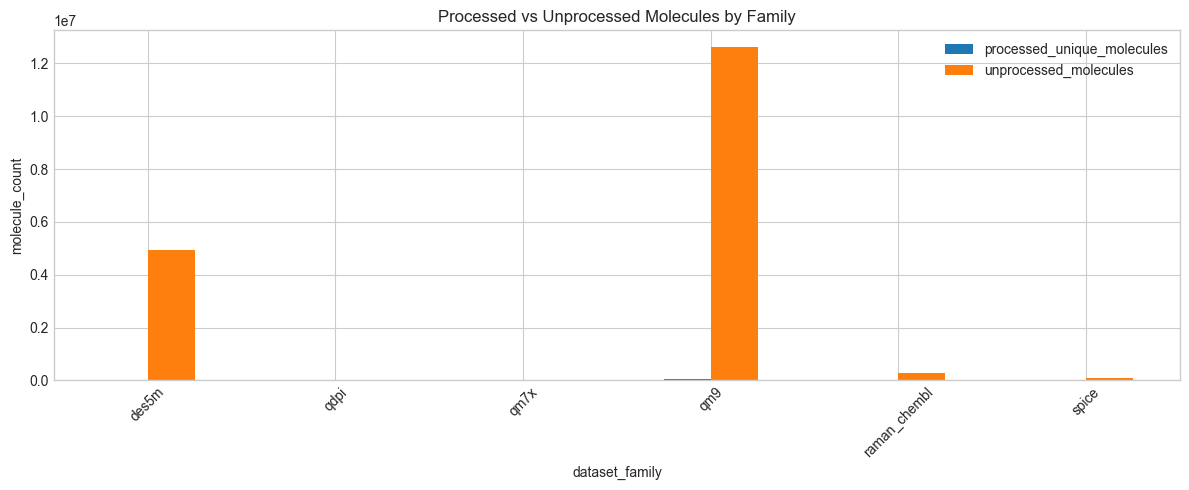

Top families by unprocessed molecules:


,family,unprocessed_molecules,unprocessed_conformations
3,qm9,12616664,12616664
0,des5m,4945938,4945938
4,raman_chembl,282556,282817
5,spice,81763,814276
1,qdpi,30278,30278
2,qm7x,5010,3361687


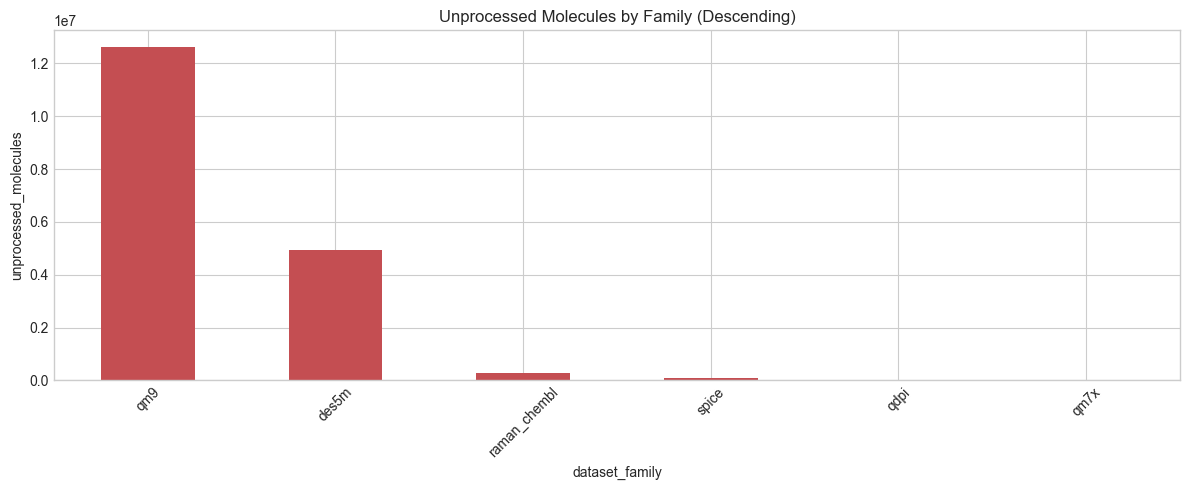

Top sources by unprocessed molecules:


,source,family,unprocessed_molecules,unprocessed_conformations
22,summary.csv.gz,qm9,12616664,12616664
8,Donchev et al. DES5M.csv,des5m,4945938,4945938
9,Raman-ChEMBL-part1.db,raman_chembl,141923,142032
10,Raman-ChEMBL-part2.db,raman_chembl,140633,140785
11,SPICE-2.0.1.hdf5,spice,81763,814276
20,spice.hdf5,qdpi,12617,12617
15,geom.hdf5,qdpi,7205,7205
12,ani.hdf5,qdpi,6033,6033
13,comp6.hdf5,qdpi,1570,1570
21,spice_charged.hdf5,qdpi,1455,1455


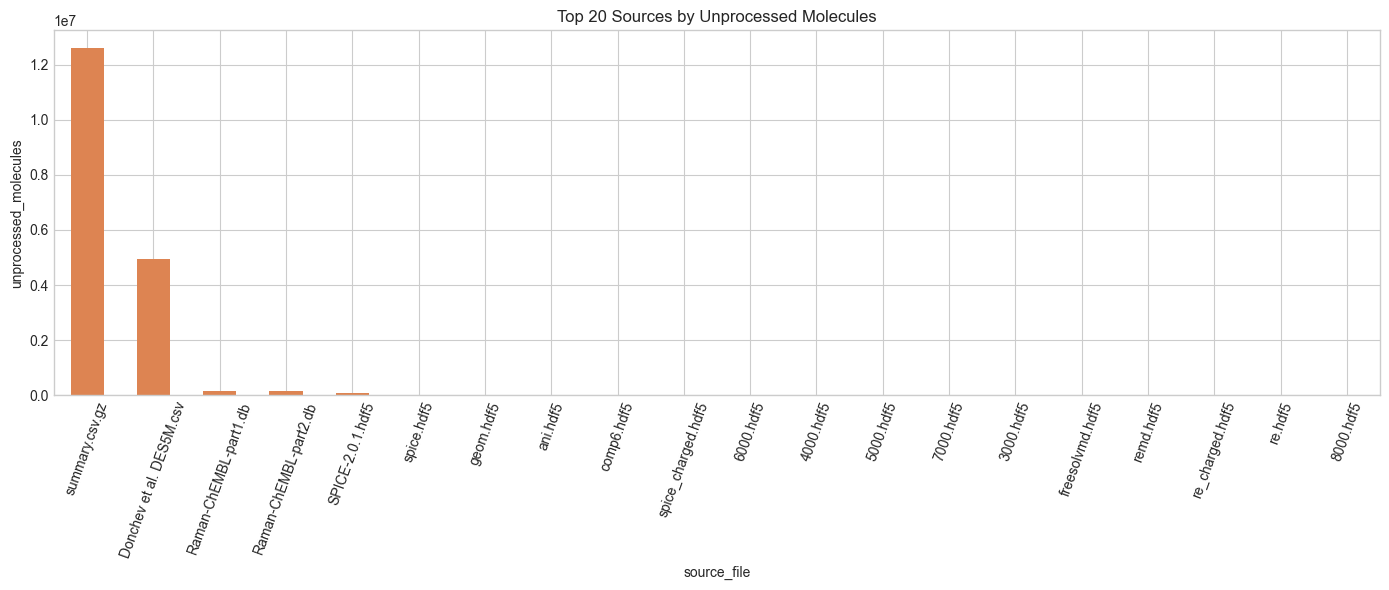

In [7]:
import json

audit_dir = None
if coverage_audit_dir is not None:
    audit_dir = _resolve_path(coverage_audit_dir)

summary_path = (audit_dir / 'audit_summary.json') if audit_dir else None
source_cov_path = (audit_dir / 'source_coverage.csv') if audit_dir else None
family_cov_path = (audit_dir / 'family_coverage.csv') if audit_dir else None

if (
    use_coverage_audit_if_available
    and summary_path is not None
    and source_cov_path is not None
    and family_cov_path is not None
    and summary_path.exists()
    and source_cov_path.exists()
    and family_cov_path.exists()
):
    print(f'Loaded coverage/hessian audit from: {audit_dir}')

    audit_summary = json.loads(summary_path.read_text())
    source_cov_df = pd.read_csv(source_cov_path)
    family_cov_df = pd.read_csv(family_cov_path)

    h = audit_summary.get('hessian', {})
    c = audit_summary.get('coverage', {})

    hessian_kpis = pd.DataFrame(
        [
            {
                'shards_found': audit_summary.get('shards_found', None),
                'items_valid': audit_summary.get('scan_counts', {}).get('items_valid', None),
                'items_with_joint_hessian': h.get('items_with_joint_hessian', None),
                'unique_joint_hessian': h.get('unique_joint_hessian', None),
                'unique_hi': h.get('unique_hi', None),
                'unique_hij': h.get('unique_hij', None),
            }
        ]
    )

    coverage_kpis = pd.DataFrame(
        [
            {
                'total_unprocessed_molecules': c.get('total_unprocessed_molecules', None),
                'total_unprocessed_conformations': c.get('total_unprocessed_conformations', None),
                'estimated_unprocessed_shards': c.get('estimated_unprocessed_shards', None),
                'avg_items_per_shard': c.get('avg_items_per_shard', None),
            }
        ]
    )

    print('Hessian KPIs:')
    display(hessian_kpis)

    print('Coverage KPIs:')
    display(coverage_kpis)

    print('Family coverage (source vs processed):')
    display(family_cov_df.sort_values('source_molecules', ascending=False))

    print('Source coverage (source vs processed):')
    display(source_cov_df.sort_values('source_molecules', ascending=False))

    # Quick chart: unprocessed molecules by family.
    plot_cov = family_cov_df.copy()
    ax = plot_cov.set_index('family')[['processed_unique_molecules', 'unprocessed_molecules']].plot(
        kind='bar', figsize=(12, 5)
    )
    ax.set_title('Processed vs Unprocessed Molecules by Family')
    ax.set_ylabel('molecule_count')
    ax.set_xlabel('dataset_family')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # Top unprocessed families (descending)
    top_family_unprocessed = (
        family_cov_df[['family', 'unprocessed_molecules', 'unprocessed_conformations']]
        .sort_values('unprocessed_molecules', ascending=False)
    )
    print('Top families by unprocessed molecules:')
    display(top_family_unprocessed)

    ax = top_family_unprocessed.set_index('family')['unprocessed_molecules'].plot(
        kind='bar', figsize=(12, 5), color='#c44e52'
    )
    ax.set_title('Unprocessed Molecules by Family (Descending)')
    ax.set_ylabel('unprocessed_molecules')
    ax.set_xlabel('dataset_family')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # Top unprocessed sources (descending)
    top_source_unprocessed = (
        source_cov_df[['source', 'family', 'unprocessed_molecules', 'unprocessed_conformations']]
        .sort_values('unprocessed_molecules', ascending=False)
    )
    print('Top sources by unprocessed molecules:')
    display(top_source_unprocessed.head(25))

    ax = top_source_unprocessed.head(20).set_index('source')['unprocessed_molecules'].plot(
        kind='bar', figsize=(14, 6), color='#dd8452'
    )
    ax.set_title('Top 20 Sources by Unprocessed Molecules')
    ax.set_ylabel('unprocessed_molecules')
    ax.set_xlabel('source_file')
    ax.tick_params(axis='x', rotation=70)
    plt.tight_layout()
    plt.show()
else:
    print('Coverage/Hessian audit files not found. Expected:')
    if summary_path is not None:
        print(' -', summary_path)
    if source_cov_path is not None:
        print(' -', source_cov_path)
    if family_cov_path is not None:
        print(' -', family_cov_path)
